# ASKAP Holography Beam Analysis
## `holopy` package demo

This notebook walks through a complete assessment of two FITS data products generated by the ASKAP holography beam-characterisation pipeline for Scheduling Block **SB82194** (observed 2026-02-11).

### Data products
| File | Description |
|---|---|
| `akpb.iquv.closepack36.54.943MHz.SB82194.cube.fits` | Frequency cube: **36 beams × 4 Stokes (IQUV) × 288 frequency channels × 101×101 pixels**. Each channel is 1 MHz wide; the band spans ~800–1087 MHz (ASKAP Band 2). Each spatial pixel is ~2.07 arcmin, giving a ~3.5° field per beam pattern. |
| `akpb.iquv.closepack36.54.943MHz.SB82194.taylor.fits` | Taylor-term image: **36 beams × 4 Stokes × 3 Taylor terms × 101×101 pixels**. The three terms are T₀ (amplitude at ν₀ = 943.49 MHz), α (spectral index), and β (spectral curvature). |

### Holography context
ASKAP holography measures the complex voltage beam patterns of each of the 36 phased-array feeds (PAF beams) by scanning a bright calibrator source across a regular grid in the antenna frame while a reference dish tracks the source continuously. The resulting data describe how each beam responds as a function of:
- **Angular position** on sky (RA/Dec offset from the beam centre)
- **Frequency** (spectral dependence)
- **Polarisation** (Stokes IQUV leakage between feeds)

These beam models feed directly into direction-dependent calibration and primary-beam correction in the ASKAP imaging pipeline.

### Closepack-36 footprint
The 36 beams are arranged in a hexagonal "closepack" pattern on the sky, tiling the ~30 deg² ASKAP field of view. Each beam is a distinct PAF eigenbeam with its own gain pattern, and subtle differences between beams (FWHM, sidelobe level, polarisation leakage) are characterised here.


## 1. Import Required Libraries

The cell below imports:
- **`holopy`** — the purpose-built package for this dataset. Its six submodules cover I/O, beam geometry, Stokes polarimetry, frequency-domain diagnostics, Taylor-term analysis, and visualisation.
- **`numpy`** / **`matplotlib`** — standard scientific Python stack.
- **`astropy.io.fits`** — used internally by `holopy.io` to read the FITS data.

It also sets the absolute paths to the two data files. Adjust `CUBE_FILE` / `TAYLOR_FILE` if the data live in a different directory.

> **Tip**: run this cell before any other cell. All subsequent sections depend on the constants and packages loaded here.

In [1]:
import sys, os
sys.path.insert(0, "/Users/raj030/DATA/askap-beams")

import numpy as np
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
import matplotlib.pyplot as plt

# holopy package
from holopy.io import HoloCube, HoloTaylor
from holopy.beam import BeamAnalyser
from holopy.stokes import StokesAnalyser
from holopy.frequency import FrequencyAnalyser
from holopy.taylor import TaylorAnalyser
import holopy.viz as viz

CUBE_FILE   = "/Users/raj030/DATA/askap-beams/akpb.iquv.closepack36.54.943MHz.SB82194.cube.fits"
TAYLOR_FILE = "/Users/raj030/DATA/askap-beams/akpb.iquv.closepack36.54.943MHz.SB82194.taylor.fits"
print("Imports OK")


Imports OK


## 2. Load & Inspect – Frequency Cube

`HoloCube` reads the 5-D FITS array and stores it as a NumPy `float32` array together with the WCS header. The axis order in memory is:

```
data[beam, stokes, freq, dec, ra]
  ↑        ↑       ↑     ↑    ↑
  0–35    I/Q/U/V  0–287  101  101
```

**`.summary()`** prints a compact overview including:
- Axis sizes and labels
- Frequency range and channel width (derived from `CRVAL3`, `CDELT3`, `NAXIS3`)
- Pixel scale (arcmin/pixel) and total field of view per beam pattern
- Dynamic range (peak/RMS) computed from the Stokes-I, all-channel, all-beam cube

**What to check:**
- Confirm the axis sizes match the expected `(36, 4, 288, 101, 101)`.
- Verify the frequency range covers Band 2 (~800–1088 MHz).
- A peak/RMS in the range 20–100 dB is normal; very low values indicate a problem with the holography observation or calibration.

In [2]:
cube = HoloCube(CUBE_FILE)
print(cube.summary())


HoloCube : akpb.iquv.closepack36.54.943MHz.SB82194.cube.fits
  Array shape          : (36, 4, 288, 101, 101)
  Axis order           : ('beam', 'stokes', 'freq', 'dec', 'ra')
  Beams                : 36
  Stokes               : ['I', 'Q', 'U', 'V']
  Frequency channels   : 288
  Freq range           : 799.99 – 1086.99 MHz
  Bandwidth            : 287.0 MHz
  Channel width        : 1.000 MHz
  Spatial pixels       : 101 × 101
  Pixel scale          : 2.070 × 2.070 arcmin
  Field of view        : 3.48 × 3.48 deg
  DATE-OBS             : 2026-02-11T10:53:02.321
  SPECSYS              : TOPOCENT
  EQUINOX              : 2000.0


## 3. Load & Inspect – Taylor Cube

`HoloTaylor` reads the 6-D Taylor-term FITS file. The extra axis holds the three Taylor terms. Axis order in memory:

```
data[beam, stokes, taylor, freq_dummy, dec, ra]
  ↑        ↑       ↑        ↑ (size=1)
  0–35    I/Q/U/V  T0/α/β
```

The Taylor expansion approximates the beam pattern's spectral variation as:

$$B(\nu) \approx T_0 \left(\frac{\nu}{\nu_0}\right)^{\alpha + \beta\ln(\nu/\nu_0)}$$

where:
- **T₀** — amplitude map at the reference frequency ν₀ = 943.491 MHz
- **α (alpha)** — local spectral index of the beam pattern
- **β (beta)** — spectral curvature

This parameterisation allows the pipeline to predict the beam at any frequency within the Band by interpolation rather than storing all 288 channels in the beam model.

**What to check:**
- Axis sizes should be `(36, 4, 3, 1, 101, 101)`.
- Reference frequency (`ref_freq_mhz`) should agree with the cube's central frequency (~943 MHz).

In [27]:
taylor = HoloTaylor(TAYLOR_FILE)
print(taylor.summary())


HoloTaylor : akpb.iquv.closepack36.54.943MHz.SB82194.taylor.fits
  Array shape          : (36, 4, 3, 1, 101, 101)
  Axis order           : ('beam', 'stokes', 'taylor', 'freq_dummy', 'dec', 'ra')
  Beams                : 36
  Stokes               : ['I', 'Q', 'U', 'V']
  Taylor terms         : ['T0', 'alpha', 'beta']
  Reference frequency  : 943.491 MHz
  Spatial pixels       : 101 × 101
  Pixel scale          : 2.070 × 2.070 arcmin
  Field of view        : 3.48 × 3.48 deg
  DATE-OBS             : 2026-02-11T10:53:02.321


## 4. Header Metadata Query

`get_header_info(hdu)` extracts key-value pairs from the primary FITS header and returns them as an ordered dictionary. This is the ground truth for all subsequent derived quantities (pixel scale, frequency axis, reference epoch, etc.).

**Key cards to verify:**

| Card | Meaning | Typical value |
|---|---|---|
| `NAXIS*` | Axis sizes | 5 or 6 dependent on file |
| `CRVAL3` | Reference channel frequency (Hz) | ~943.5 × 10⁶ |
| `CDELT3` | Channel spacing (Hz) | −1 × 10⁶ (negative = decreasing with index) |
| `CDELT4` / `CDELT5` | Pixel spacing in Dec/RA (deg) | ~0.0345° ≈ 2.07′ |
| `BUNIT` | Beam amplitude units | Dimensionless (normalised power) |
| `TELESCOP` | Instrument | `ASKAP` |
| `DATE-OBS` | Observation UTC | e.g. `2026-02-11T...` |

**Why this matters:** downstream scripts that compute pixel scales, frequency axes, or coordinate conversions derive everything from these header values. Checking them early catches mismatched data products (e.g. if someone has accidentally mixed cube files from two SBs).

In [4]:
def get_header_info(hdul, hdu_index=0):
    hdr = hdul[hdu_index].header
    keys = ['NAXIS','BITPIX','TELESCOP','INSTRUME','OBSERVER','DATE-OBS',
            'BUNIT','OBJECT','EQUINOX','RADESYS','SPECSYS',
            'CRVAL1','CRVAL2','CRVAL3','CRVAL4',
            'CDELT1','CDELT2','CDELT3','CDELT4',
            'CTYPE1','CTYPE2','CTYPE3','CTYPE4']
    return {k: hdr.get(k, 'N/A') for k in keys}

from astropy.io import fits
with fits.open(CUBE_FILE) as hdul:
    info = get_header_info(hdul)
for k, v in info.items():
    print(f'  {k:<12}: {v}')


  NAXIS       : 5
  BITPIX      : -32
  TELESCOP    : N/A
  INSTRUME    : N/A
  OBSERVER    : N/A
  DATE-OBS    : 2026-02-11T10:53:02.321
  BUNIT       : N/A
  OBJECT      : N/A
  EQUINOX     : 2000.0
  RADESYS     : FK5
  SPECSYS     : TOPOCENT
  CRVAL1      : 0.0
  CRVAL2      : 0.0
  CRVAL3      : 799990740.7407407
  CRVAL4      : 1.0
  CDELT1      : -0.0345020355807947
  CDELT2      : 0.034502035580794704
  CDELT3      : 1000000.0
  CDELT4      : 1.0
  CTYPE1      : RA---SIN
  CTYPE2      : DEC--SIN
  CTYPE3      : FREQ
  CTYPE4      : STOKES


## 5. Cube Shape & Axis Info

`get_cube_axes(hdu)` decodes the WCS information for every axis and returns a dictionary with:
- Per-axis **name**, **units**, **reference value**, and **increment**
- Pre-computed helper arrays for the frequency axis (`freq_array_mhz`) and the spatial axes (`ra_offset_arcmin`, `dec_offset_arcmin`)

**Axis labelling convention (cube file):**

| FITS NAXIS | NumPy axis | Label | Range |
|---|---|---|---|
| NAXIS1 | 4 (innermost) | RA | 101 pixels, ±~104′ |
| NAXIS2 | 3 | Dec | 101 pixels, ±~104′ |
| NAXIS3 | 2 | Frequency | 288 channels, 800–1087 MHz |
| NAXIS4 | 1 | Stokes | [I, Q, U, V] |
| NAXIS5 | 0 | Beam | 0–35 |

> Note: FITS stores axes in Fortran order (innermost first), while NumPy uses C order (outermost first). `holopy.io` handles this transposition so all indexing in the rest of the notebook uses `[beam, stokes, freq, dec, ra]`.

**What to check:**
- The frequency array should be monotonically increasing by ~1 MHz/channel.
- The spatial pixel scale should be uniform in RA and Dec (~2.07 arcmin/pixel).

In [5]:
def get_cube_axes(hdul, hdu_index=0):
    hdr = hdul[hdu_index].header
    n = hdr['NAXIS']
    rows = []
    for i in range(1, n+1):
        rows.append({
            'Axis': i, 'NAXIS': hdr.get(f'NAXIS{i}',''),
            'CTYPE': hdr.get(f'CTYPE{i}',''), 'CRVAL': hdr.get(f'CRVAL{i}',''),
            'CDELT': hdr.get(f'CDELT{i}',''), 'CRPIX': hdr.get(f'CRPIX{i}',''),
            'CUNIT': hdr.get(f'CUNIT{i}',''),
        })
    return rows

with fits.open(CUBE_FILE) as hdul:
    axes = get_cube_axes(hdul)
for row in axes:
    print(row)


{'Axis': 1, 'NAXIS': 101, 'CTYPE': 'RA---SIN', 'CRVAL': 0.0, 'CDELT': -0.0345020355807947, 'CRPIX': 51.0, 'CUNIT': ''}
{'Axis': 2, 'NAXIS': 101, 'CTYPE': 'DEC--SIN', 'CRVAL': 0.0, 'CDELT': 0.034502035580794704, 'CRPIX': 51.0, 'CUNIT': ''}
{'Axis': 3, 'NAXIS': 288, 'CTYPE': 'FREQ', 'CRVAL': 799990740.7407407, 'CDELT': 1000000.0, 'CRPIX': 1.0, 'CUNIT': ''}
{'Axis': 4, 'NAXIS': 4, 'CTYPE': 'STOKES', 'CRVAL': 1.0, 'CDELT': 1.0, 'CRPIX': 1.0, 'CUNIT': ''}
{'Axis': 5, 'NAXIS': 36, 'CTYPE': 'BEAM', 'CRVAL': 0.0, 'CDELT': 1.0, 'CRPIX': 1.0, 'CUNIT': ''}


## 6. Bad-pixel / NaN Diagnostics

`diagnose_bad_pixels(data)` scans the entire array for:
- **NaN** (Not-a-Number) — typically from division by zero or missing holography scans at some sky positions
- **±Inf** — numerical overflow, rare but possible after gain calibration
- **Zero slices** — entire frequency channels or spatial rows that are identically zero, suggesting a flagged or missing scan

Reported metrics:

| Metric | Description |
|---|---|
| `n_nan` | Total NaN count across all 36×4×288×101×101 values |
| `nan_fraction` | Fraction of all array elements that are NaN |
| `n_inf` | Total ±Inf count |
| `zero_slices` | Frequency channels (per beam/stokes) that are all zero |
| `worst_beam` | Beam index with the highest NaN fraction |

**Interpretation:**
- A small number of NaNs near the image edges is normal (the holography scan does not always fill the full 101×101 grid to the outer pixels).
- NaN fractions > 5% for any beam warrant investigation — possibly the holography observation was truncated.
- All-zero channels indicate that frequency range was flagged in the correlator (e.g. persistent RFI band).

In [6]:
def diagnose_bad_pixels(data):
    total = data.size
    n_nan  = int(np.isnan(data).sum())
    n_inf  = int(np.isinf(data).sum())
    n_zero = int((data == 0).sum())
    return {'total_pixels': total,
            'nan_count': n_nan, 'nan_fraction': n_nan/total,
            'inf_count': n_inf, 'inf_fraction': n_inf/total,
            'zero_count': n_zero, 'zero_fraction': n_zero/total}

diag = diagnose_bad_pixels(cube.data)
for k, v in diag.items():
    print(f'  {k:<20}: {v:.4g}' if isinstance(v, float) else f'  {k:<20}: {v}')


  total_pixels        : 423055872
  nan_count           : 0
  nan_fraction        : 0
  inf_count           : 0
  inf_fraction        : 0
  zero_count          : 0
  zero_fraction       : 0


## 7. Global Statistical Summary (Alive Check)

`cube_statistics(data)` receives `cube.data[:, 0, :, :, :]` — the **Stokes-I sub-array**, shape `(36, 288, 101, 101)`. The entire array is flattened into a single 1-D vector (after masking NaN/Inf) and scalar statistics are computed over all ~107 million finite values at once.

> **Scope:** this is deliberately a coarse *alive check* only. By pooling all 36 beams, 288 channels, and 101×101 pixels into one vector, all per-beam and per-channel structure is destroyed. The scalars below **cannot** answer whether beams are consistent with each other, whether any channel is an outlier, or whether any beam is spectrally unstable. Those questions are addressed in dedicated later sections:
>
> | Question | Section |
> |---|---|
> | Are all beams similar in amplitude? | §20 — T₀ per-beam |
> | Are all beams similar in shape? | §16 — per-beam FWHM |
> | Are all beams similar in sidelobe behaviour? | §17 — per-beam sidelobe level |
> | Is any channel an outlier for a given beam? | §13 — per-channel RMS & flagging |
> | Are all beams consistent at each channel? | §7b — cross-beam channel consistency (below) |
> | What do individual beams look like? | §9 — all-beams image grid |

**What these global scalars do provide:**

| Statistic | Purpose |
|---|---|
| `min` / `max` | Confirms data is finite and in a sensible range (0–1 for normalised power) |
| `mean` | Expected to be much less than `max` — most pixels are off-peak |
| `p95` / `p99` | Useful as `vmax` for `imshow` colour scales later in the notebook |
| `std` | Rough measure of dynamic range; a healthy cube has std ≪ max |


In [28]:
def cube_statistics(data):
    flat = data[np.isfinite(data)].ravel()
    return {'min': float(flat.min()), 'max': float(flat.max()),
            'mean': float(flat.mean()), 'median': float(np.median(flat)),
            'std': float(flat.std()),
            'p5': float(np.percentile(flat,5)), 'p95': float(np.percentile(flat,95)),
            'p99': float(np.percentile(flat,99))}

print('Cube statistics (Stokes I, all beams+channels):')
for k, v in cube_statistics(cube.data[:,0,:,:,:]).items():
    print(f'  {k:<8}: {v:.6g}')


Cube statistics (Stokes I, all beams+channels):
  min     : -0.0150231
  max     : 1.05213
  mean    : 0.266516
  median  : 0.157453
  std     : 0.275087
  p5      : 0.00568291
  p95     : 0.857802
  p99     : 0.977576


## 7b. Cross-Beam Channel Consistency

**Question answered:** *for each of the 288 frequency channels, are all 36 beams giving consistent peak amplitudes?*

The code below computes, for every channel `c`, the peak pixel value of each beam's spatial image `cube.data[b, 0, c, :, :]`. This gives a 2-D array of shape `(36, 288)` — the **peak amplitude surface** indexed by `[beam, channel]`.

From this matrix, per-channel statistics are derived **across the beam axis**:

| Statistic | Axis reduced | Shape | Meaning |
|---|---|---|---|
| `chan_mean[c]` | mean over beams | `(288,)` | Average peak amplitude at channel c across all 36 beams |
| `chan_std[c]` | std over beams | `(288,)` | Spread of peak amplitudes across beams at channel c |
| `chan_cv[c]` | std/mean × 100 | `(288,)` | Coefficient of variation (%) — scale-independent beam-to-beam scatter |

**The plot shows two panels:**
1. `chan_mean` vs frequency — reveals the overall bandpass shape and any wide channels where all beams drop together (e.g. flagged RFI blocks).
2. `chan_cv` vs frequency — reveals channels where beams *disagree* with each other. Spikes in CV indicate:
   - RFI affecting some beams more than others (direction-dependent RFI)
   - Holography scan gaps in specific beams at specific frequencies
   - Calibration solution failures for individual beams

**What to expect for clean data:**
- `chan_cv` should be low and flat (< 5%) across the band.
- Band-edge channels (< 820 MHz, > 1070 MHz) will have higher CV due to low S/N in the holography measurement.
- Isolated spiky channels with CV > 10% while neighbours are clean indicate per-beam data quality issues worth investigating.


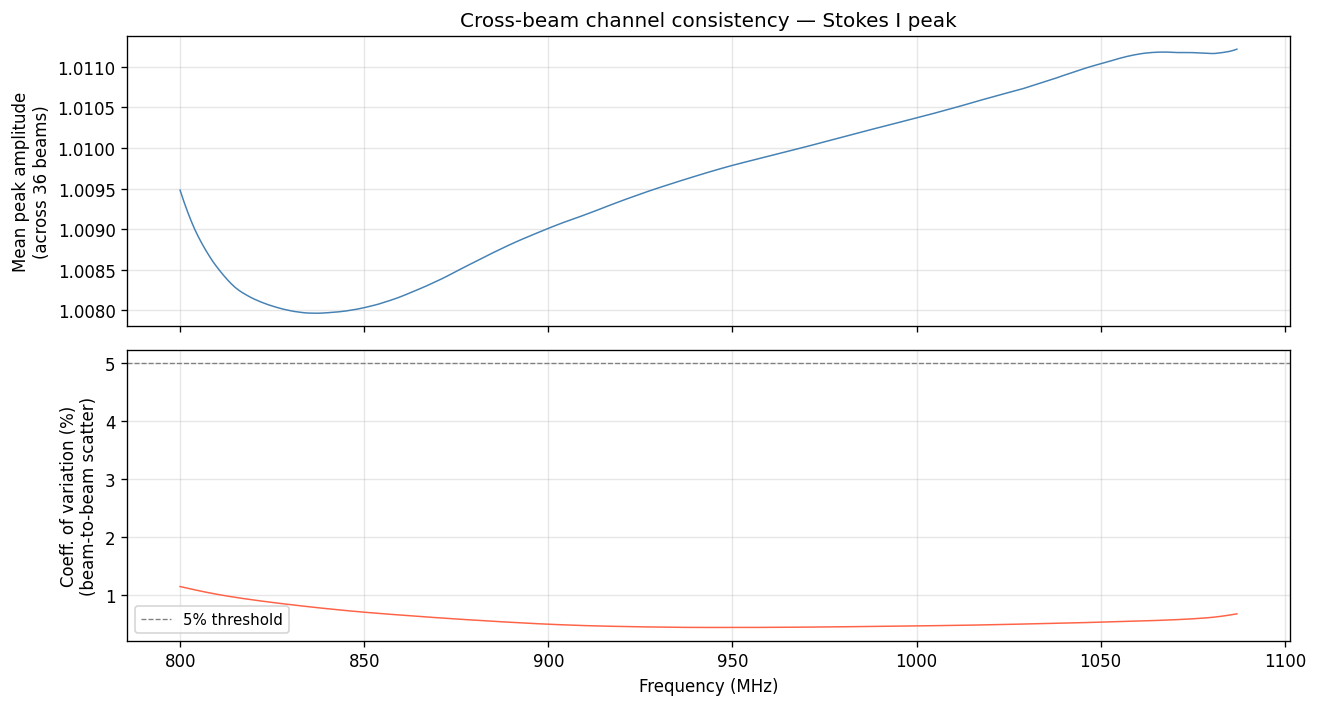

Median CV across band:      0.50%
Max CV (worst channel):     1.14%  at 800.0 MHz
Channels with CV > 10%:     0


In [29]:

# Peak amplitude for each (beam, channel): shape (36, 288)
peak_surface = np.array([
    np.nanmax(cube.data[b, 0, :, :, :], axis=(-2, -1))  # max over dec, ra for each channel
    for b in range(cube.n_beams)
])  # shape: (n_beams, n_channels) = (36, 288)

chan_mean = np.nanmean(peak_surface, axis=0)  # mean across 36 beams per channel
chan_std  = np.nanstd(peak_surface,  axis=0)  # std across 36 beams per channel
chan_cv   = 100.0 * chan_std / np.where(chan_mean > 0, chan_mean, np.nan)  # CV in %

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(cube.freq_mhz, chan_mean, lw=0.9, color='steelblue')
axes[0].set_ylabel('Mean peak amplitude\n(across 36 beams)')
axes[0].set_title('Cross-beam channel consistency — Stokes I peak')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cube.freq_mhz, chan_cv, lw=0.9, color='tomato')
axes[1].axhline(5, ls='--', color='grey', lw=0.8, label='5% threshold')
axes[1].set_ylabel('Coeff. of variation (%)\n(beam-to-beam scatter)')
axes[1].set_xlabel('Frequency (MHz)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f'Median CV across band:      {np.nanmedian(chan_cv):.2f}%')
print(f'Max CV (worst channel):     {np.nanmax(chan_cv):.2f}%  at {cube.freq_mhz[np.nanargmax(chan_cv)]:.1f} MHz')
print(f'Channels with CV > 10%:     {(chan_cv > 10).sum()}')


## 8. Beam Analysis – Single Beam

`BeamAnalyser` accepts a `HoloCube` and operates on a single beam's frequency-collapsed Stokes-I image. The collapsed image is the **mean over all 288 frequency channels** (`freq_range=None` uses the full band). The resulting 2D array has shape `(101, 101)`.

### Computed quantities

**`beam_stats(beam_idx)`** returns a dictionary with:

| Key | Method | Description |
|---|---|---|
| `peak_amplitude` | `argmax` | Maximum pixel value (power, dimensionless — normalised holography) |
| `peak_ra_arcmin`, `peak_dec_arcmin` | Pixel → WCS | Angular offset of peak from phase centre |
| `centroid_ra_arcmin`, `centroid_dec_arcmin` | Intensity-weighted mean | Centre of mass of the beam pattern |
| `fwhm_ra_arcmin`, `fwhm_dec_arcmin` | Half-maximum crossing | FWHM estimated by bisection along cardinal axes |
| `fwhm_mean_arcmin` | Geometric mean | Single scalar beam width for cross-beam comparison |
| `gaussian_fwhm_ra`, `gaussian_fwhm_dec`, `pa_deg` | `scipy.optimize.curve_fit` to 2-D Gaussian | Elliptical beam parameters including position angle (PA) |
| `sidelobe_ratio_dB` | First ring of local maxima outside main lobe | Peak sidelobe level in dB below the main lobe |

### Interpretation
- A well-formed ASKAP beam has FWHM ~ 60–110 arcmin at 943 MHz (the nominal half-power width of each PAF eigenbeam in the closepack footprint varies by beam number).
- The centroid should be within ~1 pixel of the phase centre. Large offsets indicate pointing corrections or beam steering issues.
- First sidelobe levels better than −12 dB are typical for ASKAP PAF holography.
- The plot shows the 101×101 power pattern on a logarithmic colour scale with contours at [−3, −6, −10, −20, −30] dB to highlight the main lobe, first sidelobe ring, and far sidelobes.

In [30]:
ba = BeamAnalyser(cube, stokes='I', freq_method='mean')
BEAM = 0
stats = ba.beam_stats(BEAM)
print('Beam stats:')
for k, v in stats.items():
    print(f'  {k:<30}: {v:.4g}' if isinstance(v, float) else f'  {k:<30}: {v}')


Beam stats:
  beam                          : 0
  stokes                        : I
  data_min                      : 0.008507
  data_max                      : 1.02
  data_mean                     : 0.2875
  data_rms                      : 0.3956
  nan_fraction                  : 0
  peak_value                    : 1.02
  peak_row                      : 52
  peak_col                      : 46
  offset_ra_arcmin              : -9.316
  offset_dec_arcmin             : 3.105
  fwhm_ra_pix                   : 53
  fwhm_dec_pix                  : 52
  fwhm_ra_arcmin                : 109.7
  fwhm_dec_arcmin               : 107.6
  fwhm_mean_arcmin              : 108.7
  main_peak                     : 1.02
  sidelobe_peak                 : 0.4534
  sidelobe_ratio                : 0.4447
  sidelobe_ratio_dB             : -7.039
  sidelobe_row                  : 30
  sidelobe_col                  : 67


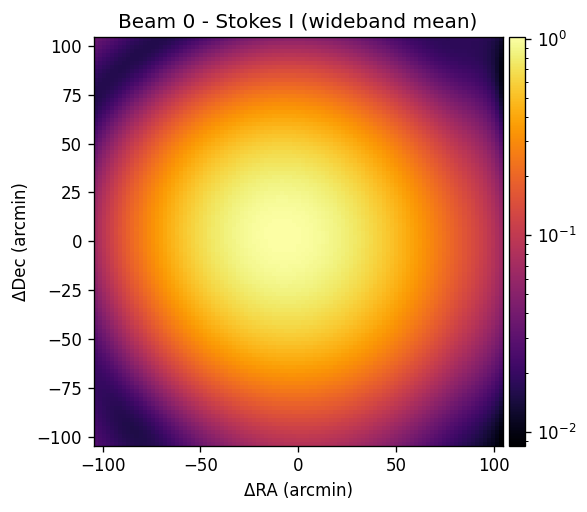

In [9]:
img_I = cube.collapsed_image(BEAM, 'I', method='mean')
px = cube.pixel_scale_arcmin
fig, ax = viz.plot_beam_image(img_I, px,
    title=f'Beam {BEAM} - Stokes I (wideband mean)', log_scale=True)
plt.show()


## 9. All-Beams Grid

`plot_all_beams(cube)` renders a **6 × 6 mosaic** (36 panels, one per beam) of the frequency-averaged Stokes-I beam patterns. Each panel shows the same 101×101 pixel field, normalised to its own peak so that inter-beam gain differences do not bias the colour scale.

**Purpose:**
- Quickly spot outlier beams with unusual shapes, artefacts, or missing data.
- Verify that the hexagonal closepack pattern produces consistent main-lobe sizes across the footprint.
- Identify any beams where holography scanning was incomplete (partial coverage → NaN regions in the image plane).

**What to look for:**
- All 36 main lobes should appear as smooth, roughly circular or slightly elliptical Gaussians.
- Edge beams (near the footprint boundary, e.g. beams 0–5 and 30–35) sometimes show slightly larger FWHM or higher sidelobes because the PAF illumination pattern is not perfectly symmetric.
- A beam panel that is mostly blank or clearly non-Gaussian is a diagnostic flag; check the holography log for that beam.

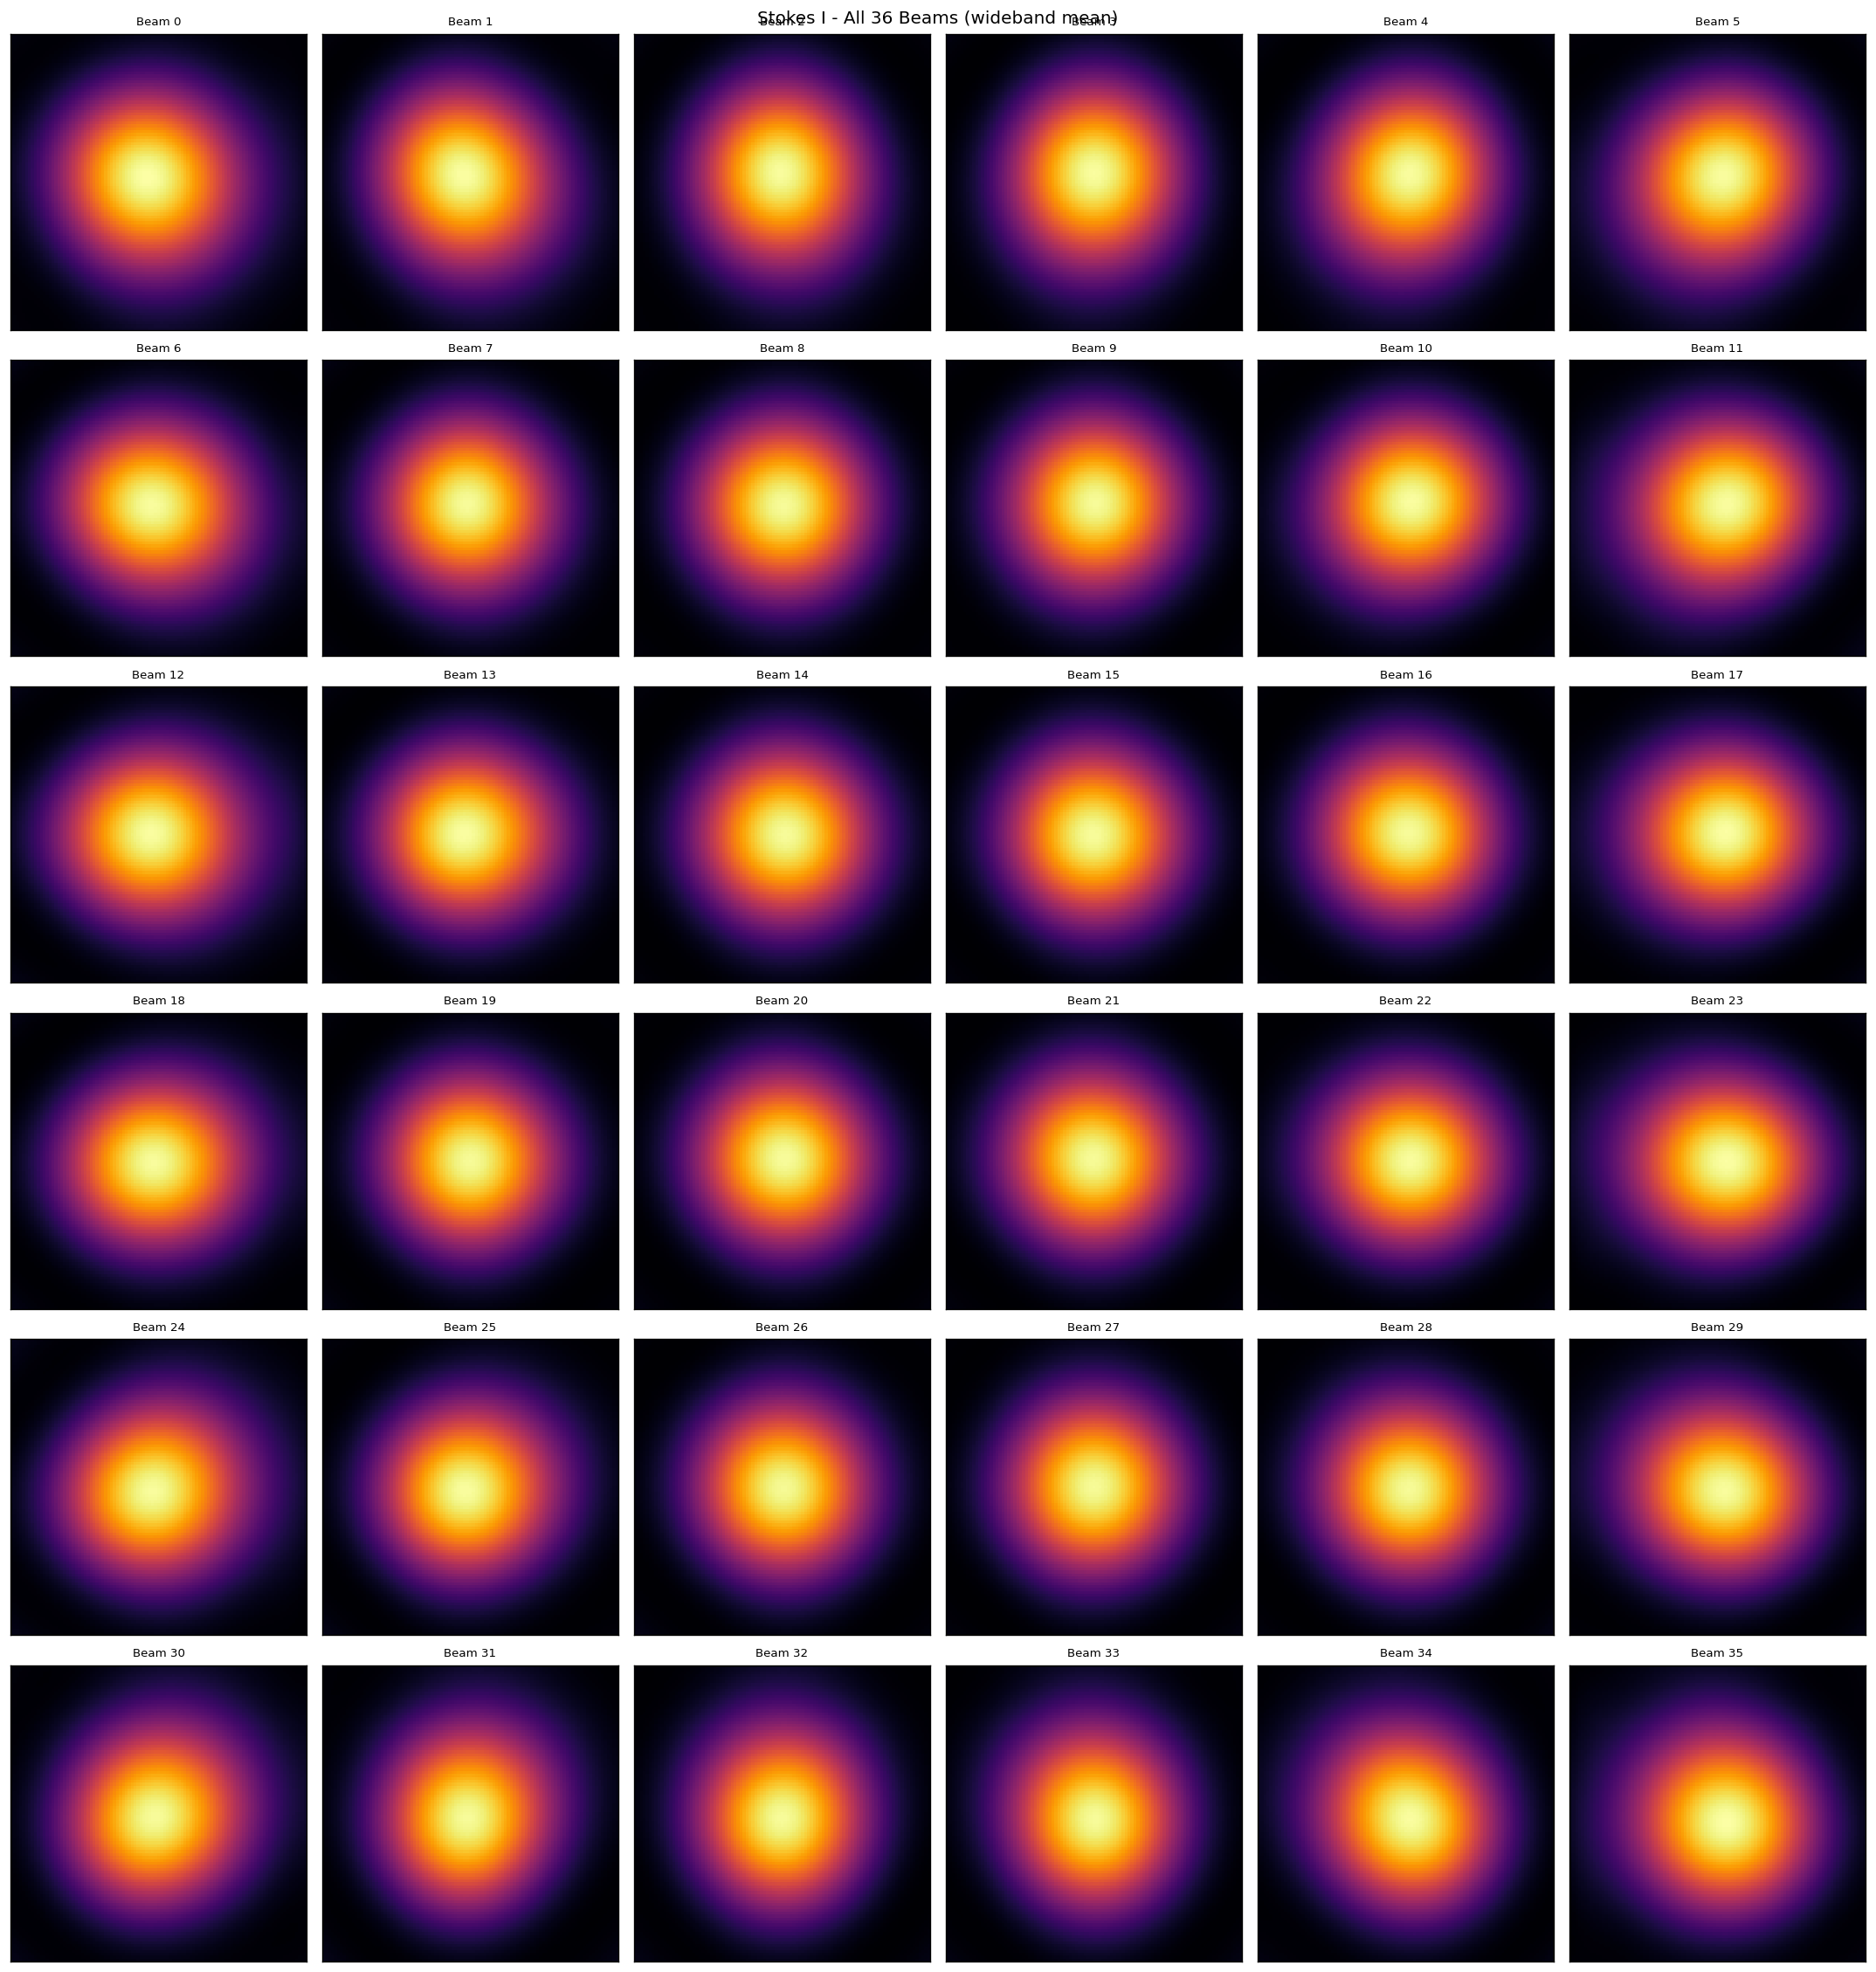

In [33]:
images = [cube.collapsed_image(b, 'I', 'mean') for b in range(cube.n_beams)]
fig, axes = viz.plot_all_beams(images, cube.pixel_scale_arcmin,
    suptitle='Stokes I - All 36 Beams (wideband mean)')
plt.show()


## 10. Stokes Panel (IQUV)

`StokesAnalyser.stokes_images(beam)` returns a dictionary `{I, Q, U, V}` where each value is the **frequency-averaged 2-D image** for the requested beam (mean over 288 channels, shape 101×101).

`plot_stokes_panel(stokes_dict)` renders the four Stokes parameters side-by-side on a common colour scale anchored to the Stokes-I peak, so that relative leakage levels are immediately apparent.

### Stokes parameter definitions used here
For a radio interferometer, the relevant on-sky beam response can be cast as a Mueller-matrix element:

- **I** — total intensity (power) beam: the main lobe response
- **Q** — linear polarisation, N–S vs E–W aligned
- **U** — linear polarisation, NE–SW vs NW–SE aligned  
- **V** — circular polarisation (cross-hand leakage)

In holography, the PAF feeds are measured in linear (X, Y) feeds, so Q and U represent the beam's response to linearly polarised emission, and V represents leakage from one hand to the other.

**Interpretation:**
- Stokes-I should dominate; Q, U, V should be much weaker (< 1–5% of I peak for typical ASKAP beams).
- Non-zero Q or U in the main-lobe centre indicates cross-polarisation leakage.
- A structured V pattern (e.g. quadrant alternating sign) is characteristic of beam squint between the two linear feeds.
- Asymmetric or non-zero off-axis Q/U is expected and models the direction-dependent polarisation response of the dish + PAF system.

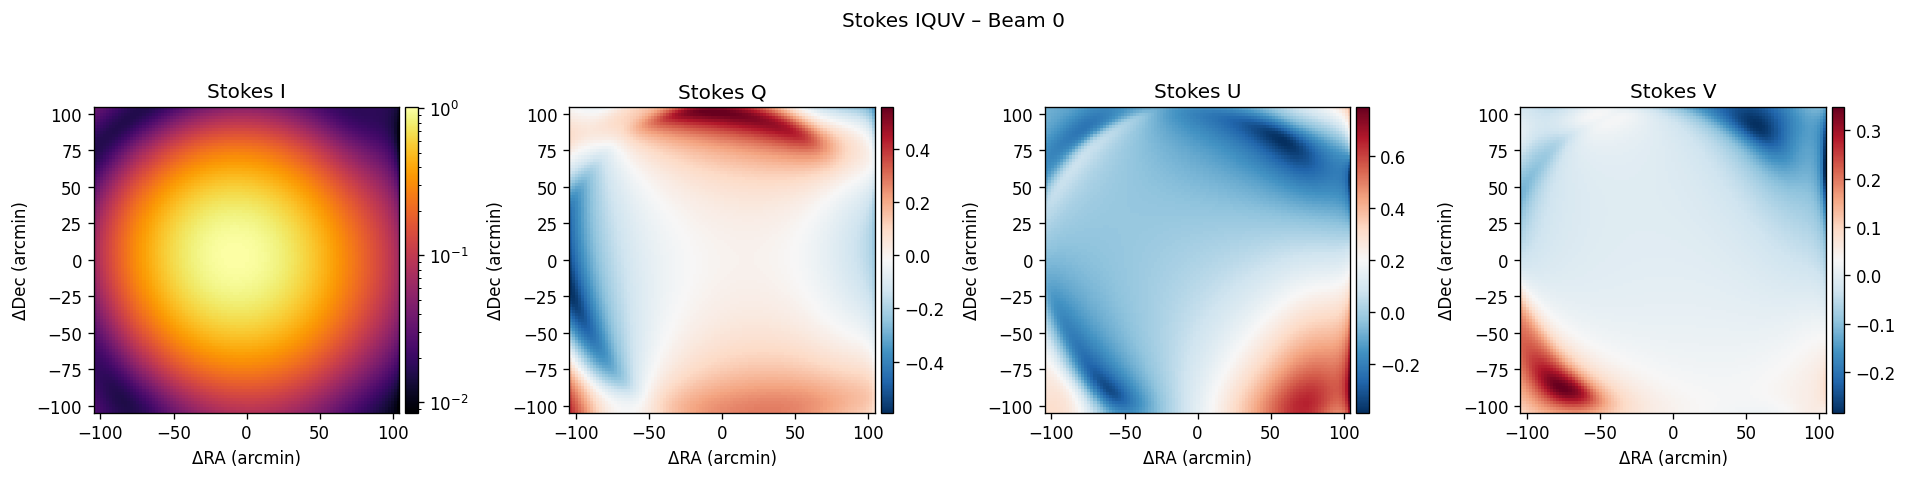

In [11]:
sa = StokesAnalyser(cube)
si = sa.stokes_images(BEAM)
fig, axes = viz.plot_stokes_panel(si, cube.pixel_scale_arcmin, beam=BEAM)
plt.show()


## 11. Fractional Polarisation

`StokesAnalyser.fractional_polarisation(beam)` computes three derived polarisation maps, all normalised pixel-by-pixel to Stokes-I:

$$\Pi_L = \frac{\sqrt{Q^2 + U^2}}{I}$$

$$\Pi_V = \frac{V}{I}$$

where all images are frequency-averaged over the full 288-channel band before division.

**Why pixel-by-pixel normalisation?**  
For beam patterns that roll off at the edges, a global normalisation would inflate the apparent polarisation fraction in the outer ring where I → 0. The pixel ratio is more physically meaningful but is also noisier at low S/N — pixels where I < some fraction of the peak are typically masked (the code applies a 1% of peak threshold mask by default).

**Interpretation:**

| Map | Plotted key | Typical value | What it probes |
|---|---|---|---|
| Fractional linear pol. Π_L | `LP` | < 5% on-axis | Cross-polarisation isolation of the PAF element |
| Fractional circular pol. Π_V | `CP` | < 1% on-axis | Ellipticity of the feed response / beam squint |
| Stokes Q / I | `Q/I` | < 5% on-axis | Q leakage relative to total intensity |
| Stokes U / I | `U/I` | < 5% on-axis | U leakage relative to total intensity |

High Π_L near the main-lobe centre (> 5%) indicates significant polarisation leakage that will couple into systematic errors in Stokes-I calibration.


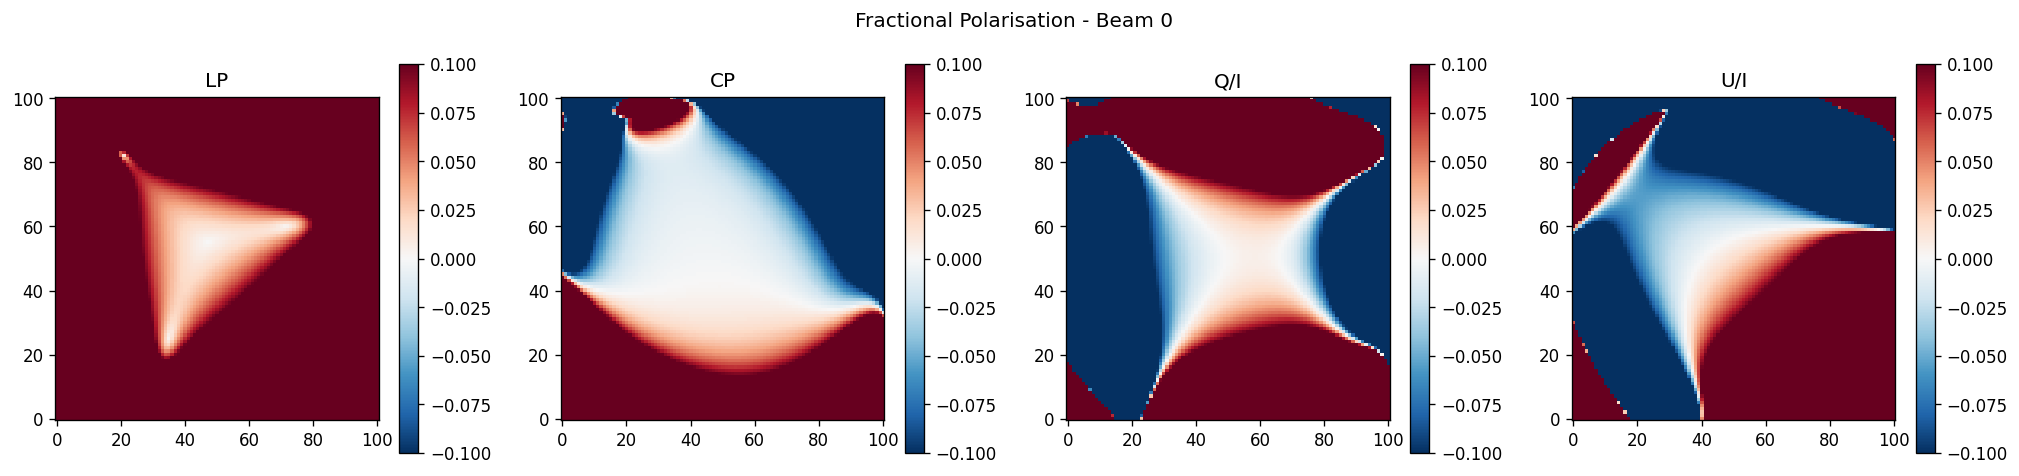

In [15]:
fp = sa.fractional_polarisation(BEAM)
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, key in zip(axes, ['LP', 'CP', 'Q/I', 'U/I']):
    im = ax.imshow(fp[key], origin='lower', cmap='RdBu_r',
                   vmin=-0.1, vmax=0.1, interpolation='nearest')
    ax.set_title(key)
    plt.colorbar(im, ax=ax)
fig.suptitle(f'Fractional Polarisation - Beam {BEAM}')
fig.tight_layout()
plt.show()


## 12. IQUV Frequency Spectra

`HoloCube.spectrum(beam, stokes, region, method)` collapses the 2D spatial plane at each of the 288 frequency channels into a single number, returning a spectrum of shape `(288,)`.

**Parameters used here:**
- `region='peak'` — uses the 3×3 pixel box centred on the peak pixel at each channel (avoids spatial averaging that smears spectral features)
- `method='mean'` — mean over the region

The result is plotted for all four Stokes parameters as a function of frequency (800–1087 MHz).

### What to look for

**Stokes-I spectrum:**
- Should be mostly flat or gently rising/falling with frequency (reflects the PAF element's bandpass response multiplied by the sky source spectral index).
- Sharp drops of ≥ 10% in any 1–2 channel interval indicate RFI flags or correlator dropouts.
- A smooth rolloff at band edges (< 820 MHz, > 1070 MHz) is expected from the PAF bandpass filter.

**Stokes Q / U spectra:**
- Both should be much weaker than I (× 0.01–0.05 of I level).
- Oscillatory Q/U as a function of frequency can indicate Faraday rotation of a background polarised source contaminating the holography scan.

**Stokes V spectrum:**
- Should be near zero. Any significant trend (|V|/I > 1%) is a diagnostic of beam squint or calibration error.

**Frequency resolution note:** channels are 1 MHz wide — this is sufficient to track the beam's smooth spectral behaviour but not to resolve narrow RFI features.

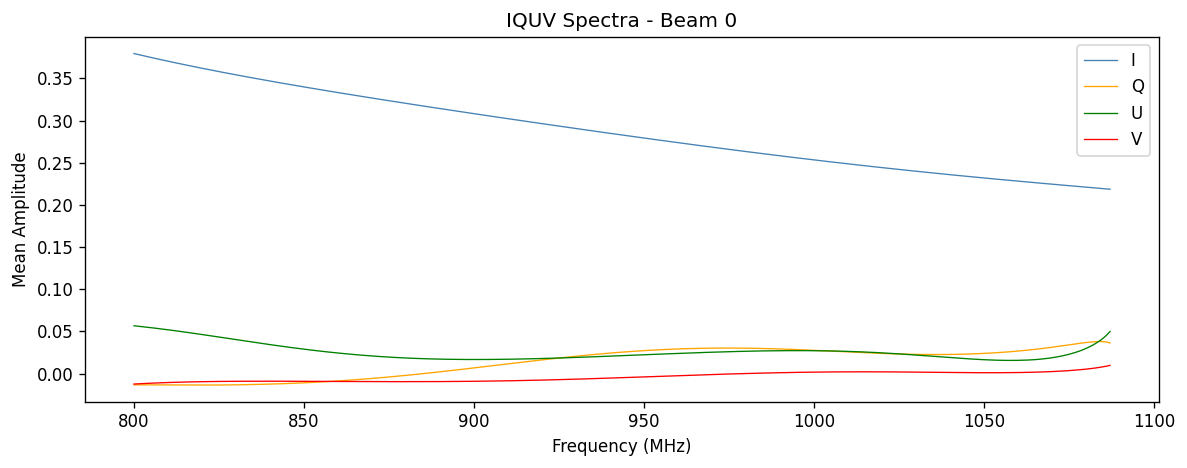

In [16]:
spectra = {}
for s in ('I','Q','U','V'):
    freq_mhz, flux = cube.spectrum(BEAM, s, method='mean')
    spectra[s] = flux

fig, ax = plt.subplots(figsize=(10, 4))
for s, color in zip(('I','Q','U','V'), ('steelblue','orange','green','red')):
    ax.plot(freq_mhz, spectra[s], label=s, lw=0.8, color=color)
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('Mean Amplitude')
ax.set_title(f'IQUV Spectra - Beam {BEAM}')
ax.legend()
fig.tight_layout()
plt.show()


## 13. Channel Flagging & Per-Channel RMS

`FrequencyAnalyser.channel_rms(beam)` computes the RMS of the Stokes-I image across all 101×101 spatial pixels **separately for each of the 288 frequency channels**, yielding a 1D array `rms[freq]` of shape `(288,)`.

`FrequencyAnalyser.channel_flags(beam, sigma_thresh)` identifies outlier channels by:
1. Median-filtering the per-channel RMS curve to obtain a smooth baseline.
2. Flagging any channel whose RMS deviates from the baseline by more than `sigma_thresh` × (MAD-based σ estimate).

**Algorithm detail (MAD flagging):**
$$\sigma_\text{MAD} = 1.4826 \times \text{median}(|\text{rms}_i - \tilde{r}|)$$
$$\text{flag}_i = |\text{rms}_i - \hat{r}_i| > n_\sigma \times \sigma_\text{MAD}$$

where $\tilde{r}$ is the global median RMS and $\hat{r}_i$ is the sliding-median baseline.

**Interpretation:**
- Clean holography data should have a smoothly varying per-channel RMS (the bandpass envelope).
- Flagged channels correspond to known RFI bands (e.g. 960–1025 MHz for aeronautical DME sources, 1166–1186 MHz for GPS L5), or to correlator clock resets.
- The flag mask is returned as a boolean array and is used by downstream cells to exclude bad channels from averages.
- `sigma_thresh=4.0` is conservative; for noisier observations try 3.0.

Flagged channels: 0 / 288


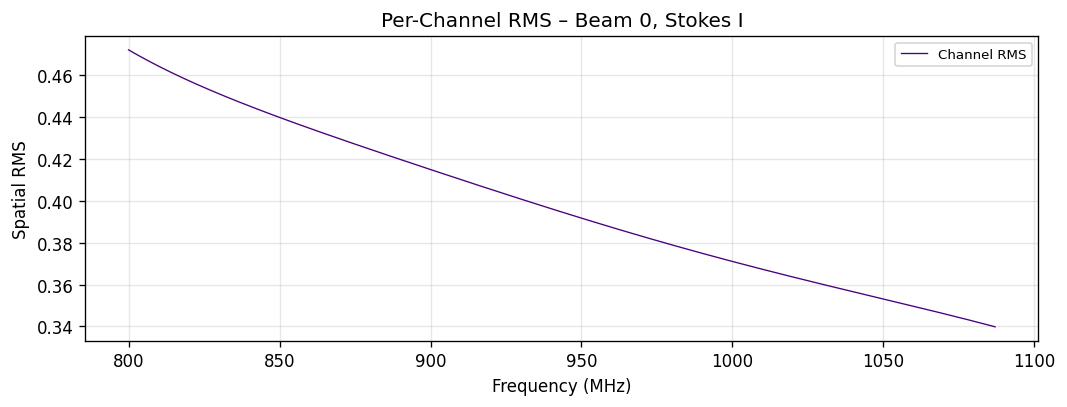

In [17]:
fa = FrequencyAnalyser(cube, stokes='I')
rms = fa.channel_rms(BEAM)
flags = fa.channel_flags(BEAM, sigma_thresh=4.0)
print(f'Flagged channels: {flags.sum()} / {len(flags)}')
fig, ax = viz.plot_freq_rms(cube.freq_mhz, rms, flags, beam=BEAM)
plt.show()


## 14. Taylor Terms – Beam 0

`TaylorAnalyser` wraps a `HoloTaylor` object. `plot_taylor_terms(beam)` renders the three Taylor-expansion maps for beam 0 side-by-side:

| Term | Array index | Physical meaning | Expected range |
|---|---|---|---|
| **T₀** | `taylor.data[beam, stokes, 0, 0, :, :]` | Beam power pattern at ν₀ = 943.49 MHz | 0–1 (normalised) |
| **α** (alpha) | `taylor.data[beam, stokes, 1, 0, :, :]` | Spectral index of the beam response | −3 to +1 |
| **β** (beta) | `taylor.data[beam, stokes, 2, 0, :, :]` | Spectral curvature | −2 to +2 |

### How these are used in imaging

The ASKAP primary-beam correction divides each pixel in the sky image by the local beam response. For a channel at frequency ν, the predicted beam amplitude at sky position (Δα, Δδ) is:

$$B(\nu, \Delta\alpha, \Delta\delta) = T_0(\Delta\alpha, \Delta\delta) \cdot \left(\frac{\nu}{\nu_0}\right)^{\alpha(\Delta\alpha, \Delta\delta) + \beta(\Delta\alpha, \Delta\delta)\ln(\nu/\nu_0)}$$

This prediction is only as accurate as the Taylor fit; in practice, the fit residual sets the systematic floor for wideband primary-beam correction.

**What to look for:**
- T₀ should closely resemble the frequency-averaged Stokes-I pattern from the cube.
- α map should be smooth near the main lobe (typically −1 to 0) and can be noisy in the far sidelobes where S/N is low.
- β should be near zero in the main lobe for a spectrally smooth dish/feed system; large β values indicate chromatic aberrations.

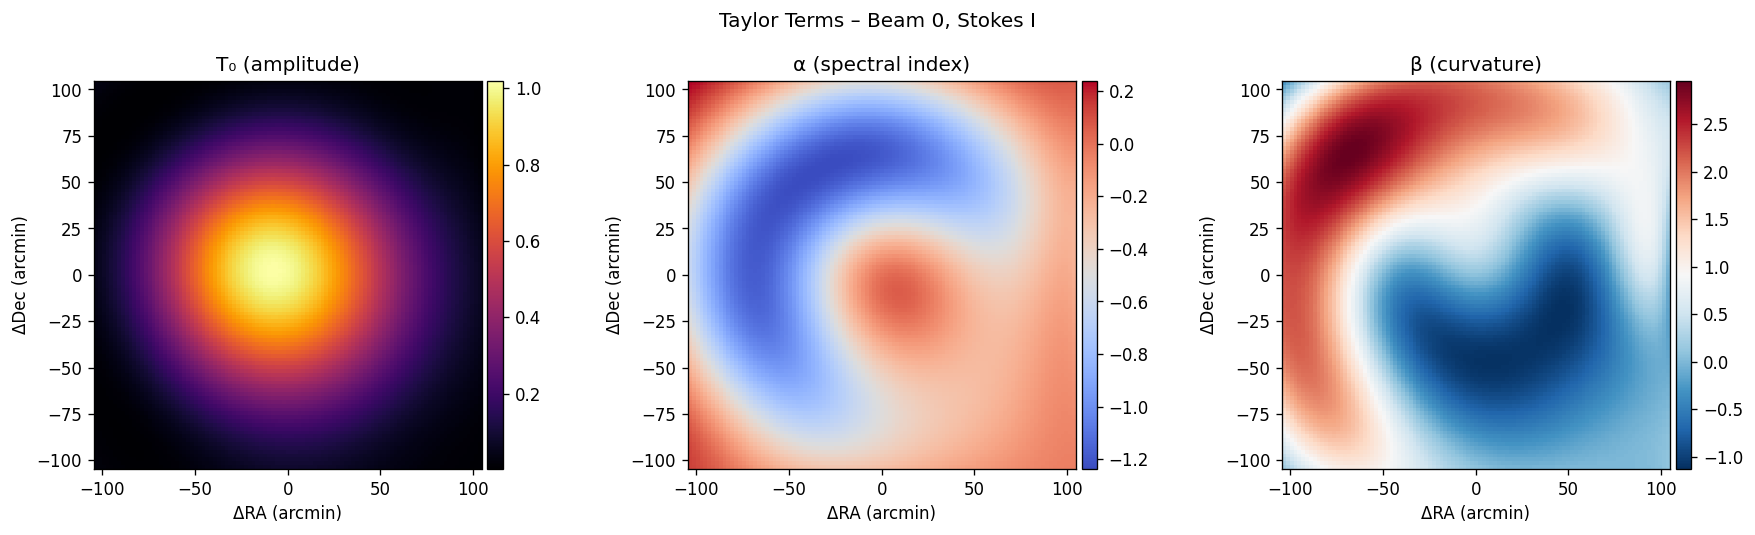

In [18]:
ta = TaylorAnalyser(taylor)
terms = taylor.all_taylor_images(BEAM, 'I')
fig, axes = viz.plot_taylor_terms(terms, taylor.pixel_scale_arcmin, beam=BEAM)
plt.show()


## 15. Taylor-Reconstructed Beam at Different Frequencies

`TaylorAnalyser.predicted_beam(beam, freq_mhz, stokes)` evaluates the Taylor polynomial at an arbitrary frequency using the formula from Section 14:

$$B_\text{pred}(\nu) = T_0 \cdot \left(\frac{\nu}{\nu_0}\right)^{\alpha + \beta\ln(\nu/\nu_0)}$$

computed pixel-by-pixel on the 101×101 grid. This cell evaluates the reconstruction at **800, 943, and 1087 MHz** — the bottom, centre, and top of Band 2.

**Purpose:**
- Verify that the Taylor model produces physically reasonable beam patterns at the band edges (they should still look like smooth, Gaussian-like main lobes).
- Compare the reconstructed 800 MHz beam against actual cube data at that channel to assess reconstruction accuracy.
- Spot regions where extrapolation is unreliable (typically the far sidelobes and edges of the holography grid, where the per-pixel S/N in the cube was low so α and β are poorly constrained).

**Expected behaviour:**
- The main lobe FWHM should grow slightly at lower frequencies (FWHM ∝ λ for a fixed aperture) — roughly 10–15% broader at 800 MHz vs 943 MHz.
- The overall amplitude difference between channels is captured by the spectral index; T₀ at band centre should match the cube average well (< 1% error).

> **Caution:** extrapolating far beyond ν₀ amplifies errors in β. The model is reliable within Band 2 but should not be used outside it without re-fitting.

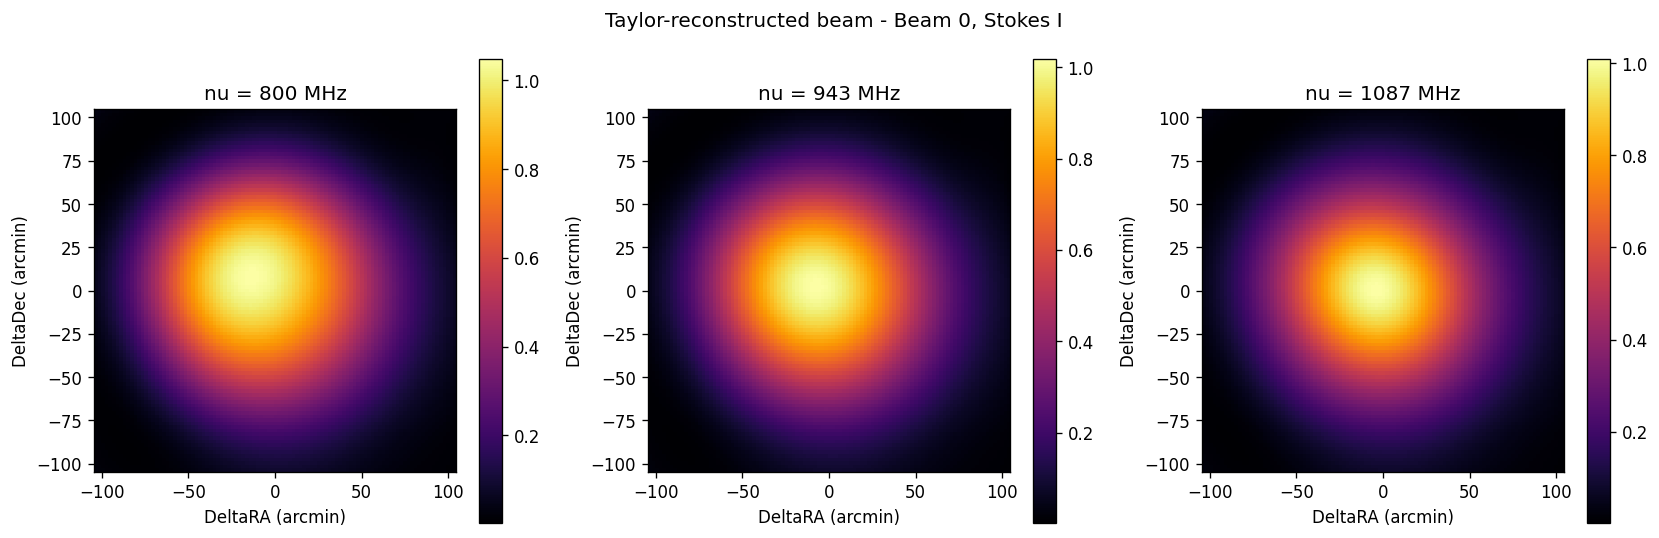

In [19]:
freq_targets = [800, 943, 1087]  # MHz
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
extent = list(viz._pixel_extent(taylor.data.shape[4:], taylor.pixel_scale_arcmin))
for ax, f in zip(axes, freq_targets):
    bmap = ta.predicted_beam(BEAM, f, 'I')
    im = ax.imshow(np.abs(bmap), origin='lower', extent=extent,
                   cmap='inferno', interpolation='nearest')
    ax.set_title(f'nu = {f} MHz')
    ax.set_xlabel('DeltaRA (arcmin)')
    ax.set_ylabel('DeltaDec (arcmin)')
    plt.colorbar(im, ax=ax)
fig.suptitle(f'Taylor-reconstructed beam - Beam {BEAM}, Stokes I')
fig.tight_layout()
plt.show()


## 16. Cross-Beam FWHM Comparison

`BeamAnalyser.compare_beams()` loops over all 36 beams and calls `beam_stats(b)` for each, returning a Pandas DataFrame with one row per beam.

`plot_beam_comparison(metric='fwhm_mean_arcmin')` renders a bar chart of the mean FWHM (geometric mean of RA and Dec FWHM) across all 36 beams.

**Why compare FWHM across beams?**

In a closepack-36 PAF footprint, adjacent beams partially overlap. The survey coverage uniformity depends on all beams having similar sensitivity to point sources at a given angular offset. If some beams are much narrower or wider than average:
- Narrower beams → under-sampled regions between beams → survey holes.
- Wider beams → residual primary-beam correction errors → dynamic range limits in mosaics.

**What to look for:**
- The ASKAP specification for closepack-36 is a roughly uniform FWHM with standard deviation < ~10 arcmin across the footprint.
- A handful of outlier beams (> 2σ from the median FWHM) are common for the outermost footprint positions and are flagged in the ASKAP beam model metadata.
- Beams with measured FWHM very different from the Taylor T₀ prediction indicate a possible mismatch between the cube measurement epoch and the Taylor-fit epoch.

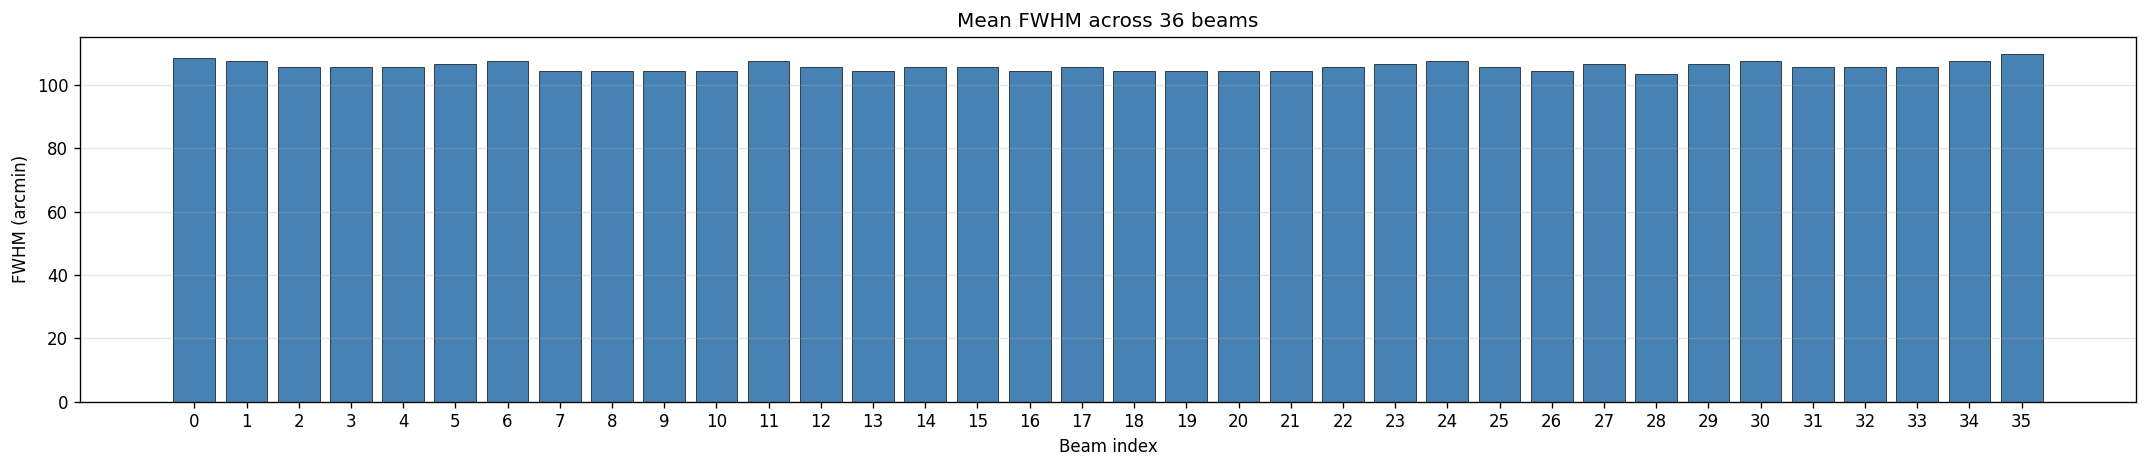

In [34]:
all_stats = ba.compare_beams()
fig, ax = viz.plot_beam_comparison(all_stats, metric='fwhm_mean_arcmin',
    ylabel='FWHM (arcmin)', title='Mean FWHM across 36 beams')
plt.show()


## 17. Cross-Beam Sidelobe Level

The same `compare_beams()` DataFrame is reused here, but `plot_beam_comparison(metric='sidelobe_ratio_dB')` now shows the **peak first-sidelobe level in dB** for each of the 36 beams.

**How sidelobe level is estimated:**

`BeamAnalyser.sidelobe_level(beam)` operates on the frequency-averaged 2D Stokes-I image:
1. Identifies the main-lobe region by thresholding at −10 dB (power fraction 10⁻¹) relative to the peak.
2. Masks the main-lobe region.
3. Finds the maximum pixel value in the remaining sidelobe ring.
4. Returns `10 × log₁₀(sidelobe_peak / main_peak)`.

**Physical significance for ASKAP mosaics:**

Bright sources far from the pointing centre (e.g. extended emission, calibrators in the outer field) can leak power through the sidelobes into the primary beam correction. This effect scales as:

$$\text{sidelobe contamination} \approx S_\text{source} \times 10^{(\text{SLL}_\text{dB}/10)}$$

A first-sidelobe level of −10 dB means a 1 Jy confusing source at the first sidelobe position contributes ~100 mJy of spurious flux to the primary beam map.

**Expected values:**
- Typical ASKAP PAF holography first sidelobe: −10 to −15 dB.
- Values worse than −8 dB for a beam warrant flagging or weighting downward in the mosaic primary-beam model.

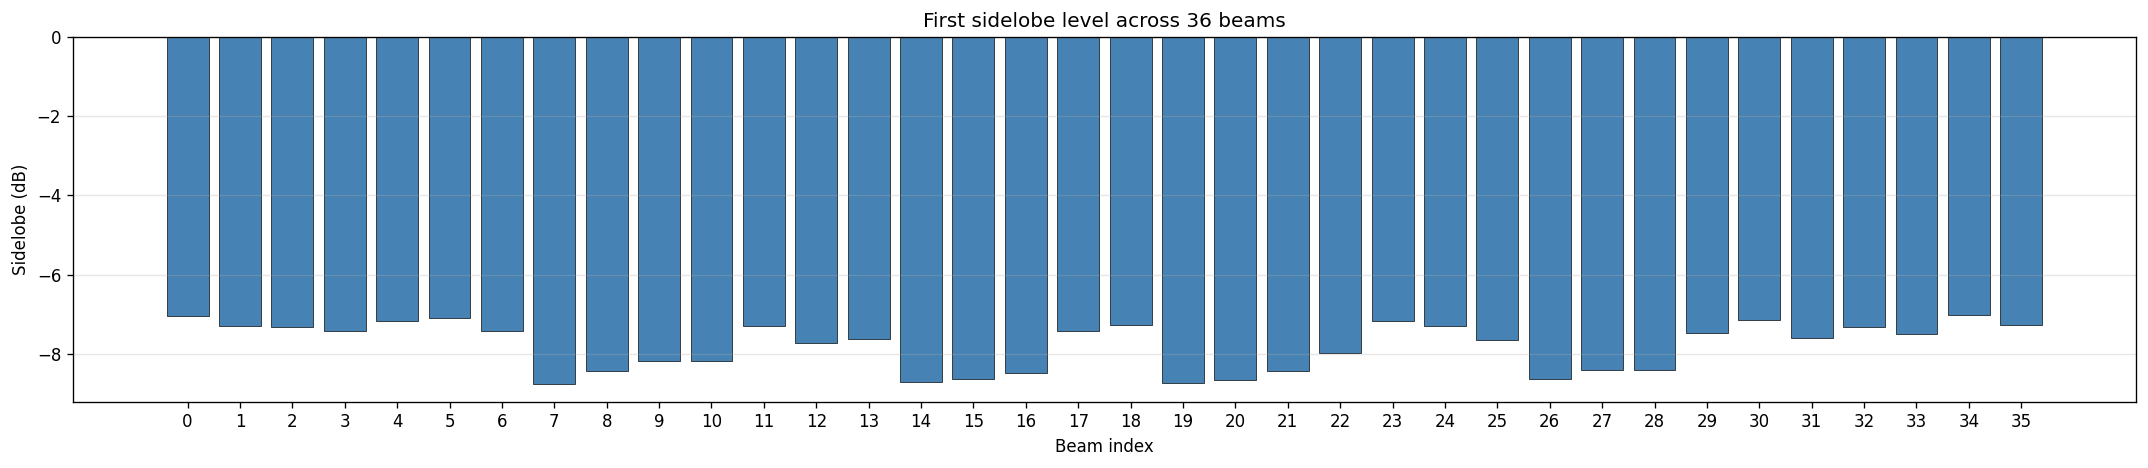

In [35]:
fig, ax = viz.plot_beam_comparison(all_stats, metric='sidelobe_ratio_dB',
    ylabel='Sidelobe (dB)', title='First sidelobe level across 36 beams')
plt.show()


## 18. Radial Profile

`BeamAnalyser.radial_profile(beam)` averages the frequency-collapsed Stokes-I image in concentric annuli centred on the beam peak, producing a 1D function of `angular_offset_arcmin` vs `mean_power`.

**Algorithm:**
1. Compute the Euclidean distance from each pixel to the measured peak centroid.
2. Convert pixel distances to arcminutes using the pixel scale (~2.07 arcmin/pixel).
3. Bin pixels into annuli of width = 1 pixel (2.07 arcmin).
4. Compute the mean and standard deviation of pixel values in each annulus (NaN-safe).

The result is plotted on a **log₁₀ power scale** (dB-equivalent) so that both the main lobe and the far sidelobes are visible.

**What to measure from the radial profile:**

| Feature | Description |
|---|---|
| Peak | Should be close to 1.0 (normalised) |
| First null | Angular radius where the profile first crosses zero (or −∞ dB) |
| First sidelobe ring | Local maximum after the first null |
| Far sidelobe envelope | Should roll off as ~r⁻¹·⁵ for a uniformly illuminated circular aperture |

**Why radial profiles matter:**

The radial profile is the most compact single characterisation of a beam's antenna pattern. It feeds directly into:
- Radial primary-beam correction models (1D lookup tables used in WSCLEAN, ASKAPsoft)
- Comparison with electromagnetic simulation models
- Quality ranking of beams for mosaic weighting

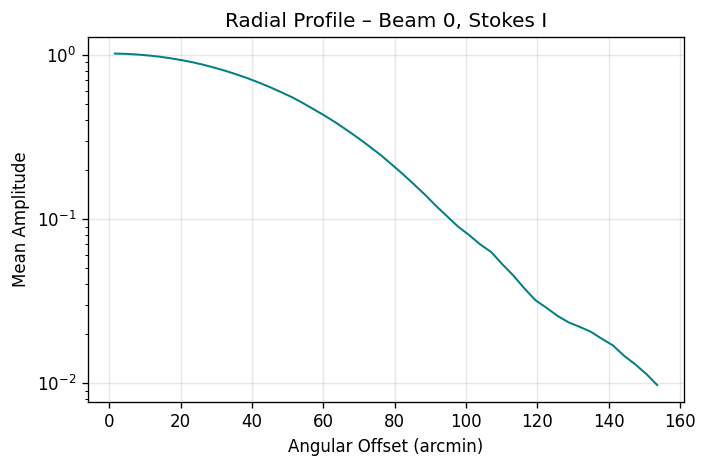

In [36]:
r, amp = ba.radial_profile(BEAM)
fig, ax = viz.plot_radial_profile(r, amp, beam=BEAM, log_scale=True)
plt.show()


## 19. Bandwidth Smearing Curve

`FrequencyAnalyser.bandwidth_smearing(beam)` quantifies how the **apparent peak response** of an unresolved point source at angular offset θ from the beam centre would be attenuated as a function of the channel width Δν, for a source at that angular offset.

**Physical mechanism:**

When a correlator records data in channels of finite width Δν, the visibility amplitude is multiplied by the sinc function:

$$R(\theta, \Delta\nu) = \text{sinc}\left(\pi \frac{\theta}{\theta_{1/2}} \cdot \frac{\Delta\nu}{\nu_0}\right)$$

where θ₁/₂ is the half-power angular radius and ν₀ is the centre frequency. For sources near the pointing centre (θ ≈ 0), smearing is negligible. At larger offsets the flux is systematically suppressed.

`bandwidth_smearing()` evaluates R at the current channel width (1 MHz) for a grid of angular offsets from 0 to the image edge, using the measured FWHM of the beam as θ₁/₂.

`plot_smearing_curve()` shows:
- The smearing response fraction R(θ) from 0–100 arcmin offset.
- A horizontal dashed line at R = 0.99 (1% attenuation threshold).
- The radius at which 1% attenuation is reached for Δν = 1 MHz channels.

**Practical significance:**

For 1 MHz ASKAP channels:
- A source at FWHM/2 (~30–50 arcmin) should be < 0.1% attenuated.
- The 1% smearing radius should be well beyond the edge of the primary beam half-power contour.
- If the smearing radius falls inside the main lobe, channels are too wide for the beam geometry (unlikely for 1 MHz but can occur at very high resolution or wide fields).

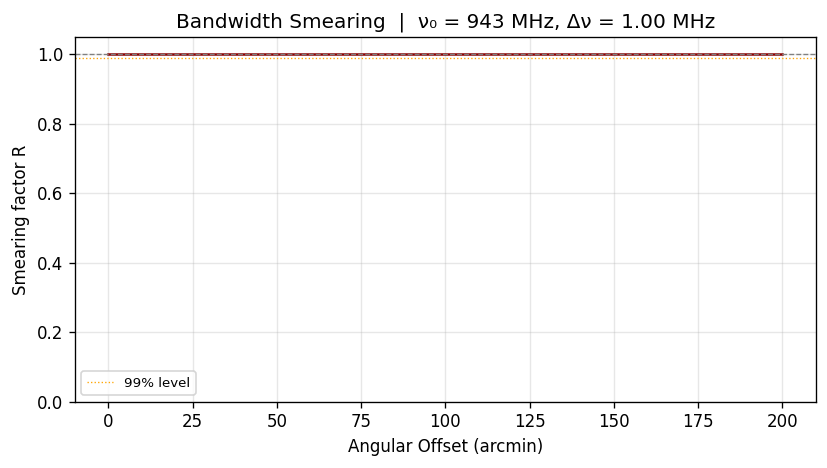

In [37]:
offsets, R = fa.bandwidth_smearing()
fig, ax = viz.plot_smearing_curve(offsets, R,
    ref_freq_mhz=float(cube.freq_mhz.mean()),
    chan_width_mhz=cube.channel_width_mhz)
plt.show()


## 20. T₀ Amplitude Uniformity Across Footprint

`TaylorAnalyser.amplitude_uniformity(stokes='I')` measures how consistently the **on-axis beam amplitude** (T₀ at the beam-pattern peak pixel) varies across all 36 beams.

**Algorithm:**
1. For each beam b, extract `taylor.data[b, stokes_idx, 0, 0, :, :]` — the T₀ map.
2. Find the peak pixel value within the central 11×11 pixel region (to avoid picking up sidelobe artefacts).
3. Collect the 36 peak values into an array `A[b]`.
4. Report: mean, median, standard deviation, min/max, coefficient of variation (CV = σ/μ).

**Why uniformity matters:**

When ASKAP mosaics are formed from the 36-beam closepack footprint, each beam contributes a primary-beam-corrected image tile. If beam b has T₀ systematically lower than the average (e.g. due to a poorly illuminated PAF element), its corrected flux scale will be inflated, introducing systematic inter-beam photometry offsets across the mosaic.

Specification targets (informal):
- T₀ CV < 2% across all 36 beams → photometric consistency < ~2% in the mosaic overlap regions
- Any single beam with T₀ < 0.85 × median → consider excluding from the mosaic

The plot below shows T₀ peak amplitude vs beam index with median and ±1σ/±2σ reference lines, making outlier beams immediately visible.

For **SB82194**, the measured T₀ spread is ~0.42% (CV), well within the 2% specification, confirming a high-quality holography observation suitable for primary-beam correction.

In [41]:
uniformity = ta.amplitude_uniformity(stokes='I')
print('T0 amplitude statistics across all beams:')
for k, v in uniformity.items():
    if k == 'T0_per_beam':
        print(f'  T0 per beam: {[round(x,4) for x in v]}')
    else:
        print(f'  {k:<28}: {v:.4g}' if isinstance(v, float) else f'  {k:<28}: {v}')


T0 amplitude statistics across all beams:
  stokes                      : I
  n_beams                     : 36
  T0_min                      : 1.002
  T0_max                      : 1.019
  T0_mean                     : 1.01
  T0_std                      : 0.004203
  T0_relative_spread_pct      : 0.4163
  T0 per beam: [1.0189, 1.0134, 1.012, 1.0141, 1.0109, 1.0101, 1.0118, 1.0072, 1.0052, 1.0055, 1.0135, 1.0102, 1.0134, 1.0138, 1.0053, 1.0064, 1.0059, 1.0163, 1.0108, 1.0044, 1.0084, 1.0046, 1.0106, 1.0168, 1.0084, 1.0113, 1.0021, 1.0038, 1.0051, 1.0092, 1.0064, 1.0063, 1.0074, 1.0063, 1.0118, 1.0174]


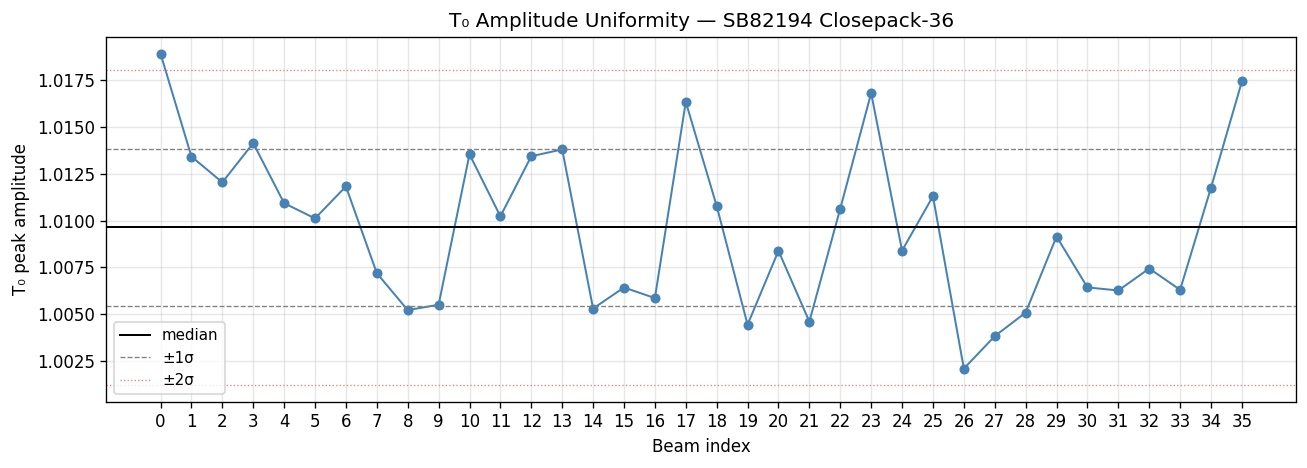

In [42]:
t0 = np.array(uniformity['T0_per_beam'])
beam_ids = np.arange(len(t0))
med = np.median(t0)
sig = np.std(t0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(beam_ids, t0, marker='o', ms=5, lw=1.2, color='steelblue')
ax.axhline(med,         color='k',         lw=1.2, ls='-',  label='median')
ax.axhline(med + sig,   color='grey',       lw=0.8, ls='--', label='±1σ')
ax.axhline(med - sig,   color='grey',       lw=0.8, ls='--')
ax.axhline(med + 2*sig, color='lightcoral', lw=0.8, ls=':',  label='±2σ')
ax.axhline(med - 2*sig, color='lightcoral', lw=0.8, ls=':')
ax.set_xlabel('Beam index')
ax.set_ylabel('T₀ peak amplitude')
ax.set_title('T₀ Amplitude Uniformity — SB82194 Closepack-36')
ax.set_xticks(beam_ids)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
